In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_excel("train_dataset.xlsx")

In [6]:
def recursive_feature_elimination(df, target_col, drop_col=None):
    X = df.drop(columns=[target_col])
    if drop_col and drop_col in X.columns:
        X = X.drop(columns=[drop_col])
    y = df[target_col]

    S = list(X.columns)
    R = []

    while len(S) > 1:
        model = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True, bootstrap=True)
        model.fit(X[S], y)
        y_pred = model.predict(X[S])

        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        importances = model.feature_importances_
        least_idx = np.argmin(importances)
        R.append((S[least_idx], rmse, r2))
        S.pop(least_idx)

    # Final feature
    model.fit(X[S], y)
    y_pred = model.predict(X[S])
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    R.append((S[0], rmse, r2))

    return pd.DataFrame(R, columns=["Feature", "RMSE", "R2"])


In [8]:
def plot_feature_elimination(result_df, title, green_line_feature=None):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.grid(True)

    ax1.set_xlabel("Features removed (in order)")
    ax1.set_ylabel("RMSE (dB)", color="tab:blue")
    ax1.plot(result_df['Feature'], result_df['RMSE'], color="tab:blue")
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_xticks(range(len(result_df['Feature'])))
    ax1.set_xticklabels(result_df['Feature'], rotation=90)

    ax2 = ax1.twinx()
    ax2.set_ylabel("R² Score", color="tab:orange")
    ax2.plot(result_df['Feature'], result_df['R2'], color="tab:orange")
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    if green_line_feature in result_df['Feature'].values:
        idx = result_df[result_df['Feature'] == green_line_feature].index[0]
        ax1.axvline(x=idx, color='green', linestyle='dotted', linewidth=2)

    plt.title(title)
    plt.tight_layout()
    plt.show()

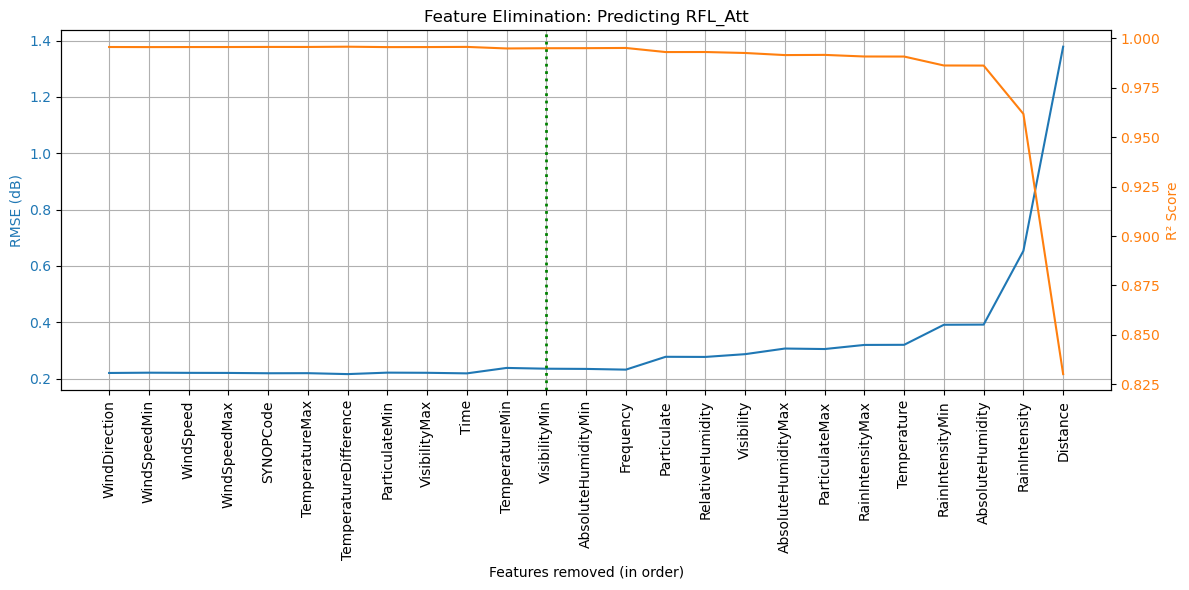

In [10]:
# === Run for RFL_Att ===
rfl_result = recursive_feature_elimination(df, target_col='RFL_Att', drop_col='FSO_Att')

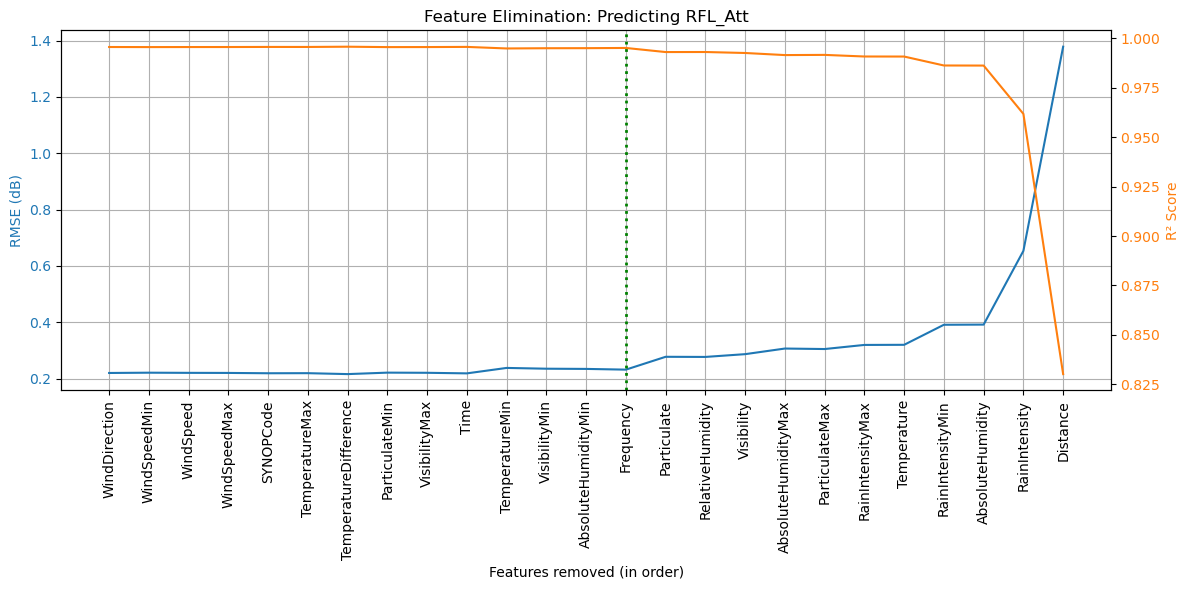

In [12]:
plot_feature_elimination(rfl_result, "Feature Elimination: Predicting RFL_Att", green_line_feature="Frequency")

In [14]:
# === Run for FSO_Att ===
fso_result = recursive_feature_elimination(df, target_col='FSO_Att', drop_col='RFL_Att')

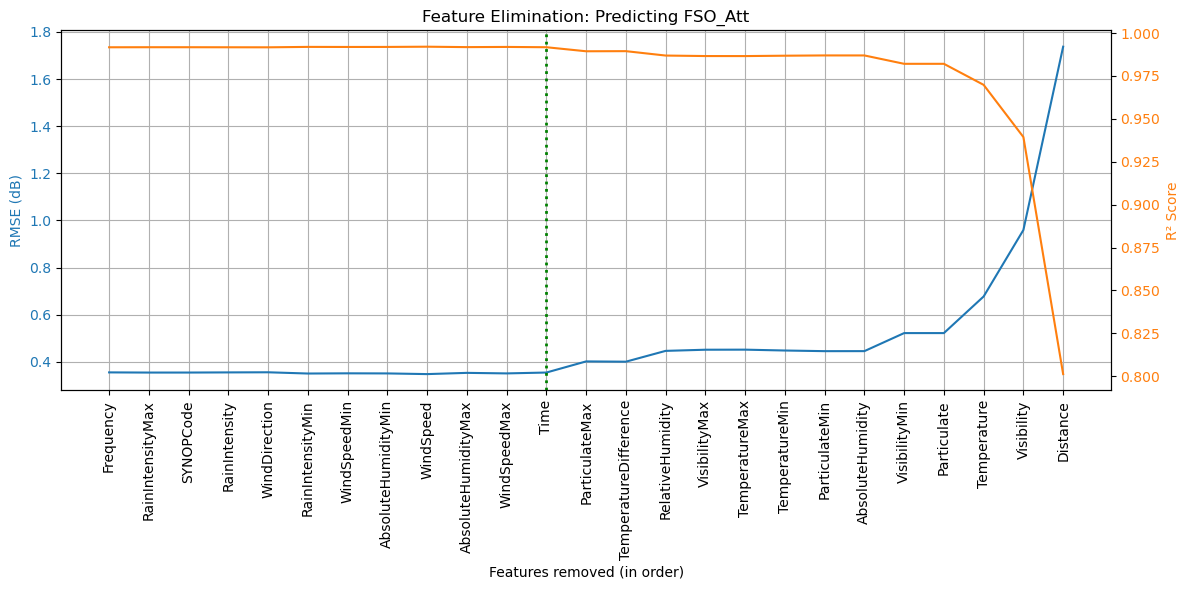

In [18]:
plot_feature_elimination(fso_result, "Feature Elimination: Predicting FSO_Att", green_line_feature="Time")

In [20]:
selected_features = [
    'Frequency', 'Particulate', 'RelativeHumidity', 'Visibility', 'AbsoluteHumidityMax',
    'ParticulateMax', 'RainIntensityMax', 'Temperature', 'RainIntensityMin',
    'AbsoluteHumidity', 'RainIntensity', 'Distance', 'RFL_Att'
]

# Filter only the selected features (if they exist in the dataset)
filtered_df = df[[col for col in selected_features if col in df.columns]]

# Save to Excel
filtered_df.to_excel("RFL_feature.xlsx", index=False)

In [22]:
selected_features = [
    'Time', 'ParticulateMax', 'TemperatureDifference', 'RelativeHumidity', 'VisibilityMax',
    'TemperatureMax', 'TemperatureMin', 'ParticulateMin', 'VisibilityMin',
    'AbsoluteHumidity', 'Particulate', 'Temperature','Visibility', 'Distance', 'FSO_Att'
]

# Filter only the selected features (if they exist in the dataset)
filtered_df_fso = df[[col for col in selected_features if col in df.columns]]

# Save to Excel
filtered_df_fso.to_excel("FSO_feature.xlsx", index=False)